# strong prompt aggregation leader "cancer_gene_expression"

[NO LLM] Iter 1 | Best F1=0.9655
[NO LLM] Iter 2 | Best F1=0.9655
[NO LLM] Iter 3 | Best F1=0.9655
[NO LLM] Iter 4 | Best F1=0.9655
[NO LLM] Iter 5 | Best F1=0.9655
[NO LLM] Iter 6 | Best F1=0.9670
[NO LLM] Iter 7 | Best F1=0.9670
[NO LLM] Iter 8 | Best F1=0.9670
[NO LLM] Iter 9 | Best F1=0.9670
[NO LLM] Iter 10 | Best F1=0.9670
[NO LLM] Iter 11 | Best F1=0.9670
[NO LLM] Iter 12 | Best F1=0.9670
[NO LLM] Iter 13 | Best F1=0.9670
[NO LLM] Iter 14 | Best F1=0.9670
[NO LLM] Iter 15 | Best F1=0.9670
[NO LLM] Iter 16 | Best F1=0.9670
[NO LLM] Iter 17 | Best F1=0.9670
[NO LLM] Iter 18 | Best F1=0.9670
[NO LLM] Iter 19 | Best F1=0.9670
[NO LLM] Iter 20 | Best F1=0.9670
[NO LLM] Iter 21 | Best F1=0.9670
[NO LLM] Iter 22 | Best F1=0.9670
[NO LLM] Iter 23 | Best F1=0.9670
[NO LLM] Iter 24 | Best F1=0.9670
[NO LLM] Iter 25 | Best F1=0.9670
[NO LLM] Iter 26 | Best F1=0.9670
[NO LLM] Iter 27 | Best F1=0.9670
[NO LLM] Iter 28 | Best F1=0.9670
[NO LLM] Iter 29 | Best F1=0.9670
[NO LLM] Iter 30 | Best

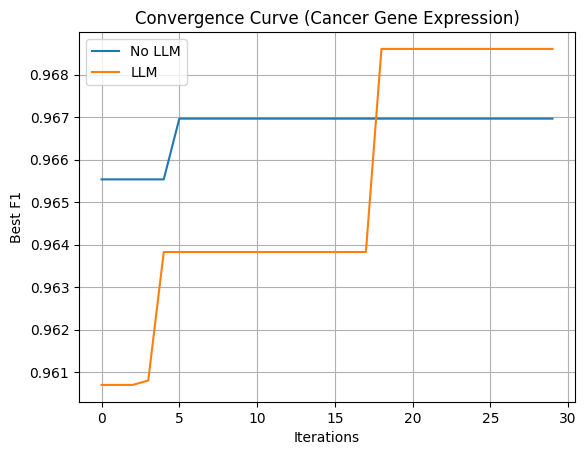

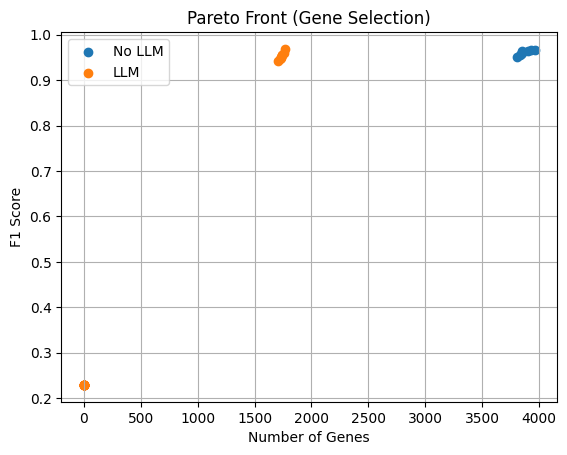

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import requests
import json
import re

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ============================================================
# GLOBAL SETTINGS
# ============================================================

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ============================================================
# DATA LOADING + SPLIT (NEW FOR SINGLE CSV)
# ============================================================

def load_data(csv_path):
    df = pd.read_csv(csv_path)

    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values
    feature_names = df.columns[:-1].values

    # IMPORTANT: gene expression normalization (critical for cancer data)
    X = StandardScaler().fit_transform(X)

    # Stratified split (VERY important for cancer datasets)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    return X_train, X_test, y_train, y_test, feature_names

# ============================================================
# FITNESS FUNCTION
# ============================================================

def fitness(mask, X, y):
    if np.sum(mask) == 0:
        return [1e6, 1e6]

    X_sel = X[:, mask == 1]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    clf = RandomForestClassifier(random_state=SEED, n_estimators=200)

    scores = []

    for tr, te in skf.split(X_sel, y):
        clf.fit(X_sel[tr], y[tr])
        pred = clf.predict(X_sel[te])
        scores.append(f1_score(y[te], pred, average='weighted'))

    f1 = np.mean(scores)

    return [np.sum(mask), -f1]

# ============================================================
# PARETO LOGIC
# ============================================================

def dominates(a, b):
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))

def update_archive(archive, p, f):
    new_archive = []

    for sol in archive:
        if dominates(sol["f"], f):
            return archive
        if not dominates(f, sol["f"]):
            new_archive.append(sol)

    new_archive.append({"p": p.copy(), "f": f})
    return new_archive

# ============================================================
# LEADER SELECTION
# ============================================================

def select_leader(archive, alpha=0.5):

    f1 = np.array([a["f"][0] for a in archive])
    f2 = np.array([a["f"][1] for a in archive])

    f1_norm = (f1 - f1.min()) / (f1.max() - f1.min() + 1e-9)
    f2_norm = (f2 - f2.min()) / (f2.max() - f2.min() + 1e-9)

    scores = alpha * f1_norm + (1 - alpha) * f2_norm
    best_idx = np.argmin(scores)

    return archive[best_idx]["p"]

# ============================================================
# PSO OPERATORS
# ============================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def update_velocity(pos, vel, pbest, leader, w=0.7, c1=2, c2=2):
    r1 = np.random.rand(len(pos))
    r2 = np.random.rand(len(pos))
    return w*vel + c1*r1*(pbest-pos) + c2*r2*(leader-pos)

def update_position(vel):
    p = (np.random.rand(len(vel)) < sigmoid(vel)).astype(int)

    if np.sum(p) == 0:
        p[np.argmax(vel)] = 1

    return p

# ============================================================
# HYPERVOLUME
# ============================================================

def hypervolume(front):
    front = np.array(front)
    front = front[front[:,0].argsort()]

    ref = [np.max(front[:,0]) + 10,
           np.max(front[:,1]) + 0.1]

    hv = 0
    prev = ref[1]

    for f1, f2 in front:
        w = ref[0] - f1
        h = prev - f2
        if w > 0 and h > 0:
            hv += w * h
        prev = f2

    return hv

# ============================================================
# NO LLM VERSION
# ============================================================

def run_no_llm(csv_path, pop=20, iters=30):

    X, Xte, y, yte, features = load_data(csv_path)
    dim = X.shape[1]

    pos = np.random.randint(0, 2, (pop, dim))
    vel = np.random.uniform(-1, 1, (pop, dim))

    pbest = pos.copy()
    pbest_fit = [fitness(p, X, y) for p in pos]

    archive = []
    curve = []

    for i in range(pop):
        archive = update_archive(archive, pos[i], pbest_fit[i])

    for it in range(iters):

        for i in range(pop):
            f = fitness(pos[i], X, y)

            if dominates(f, pbest_fit[i]):
                pbest[i] = pos[i].copy()
                pbest_fit[i] = f

            archive = update_archive(archive, pos[i], f)

        best_f1 = -min([a["f"][1] for a in archive])
        curve.append(best_f1)

        print(f"[NO LLM] Iter {it+1} | Best F1={best_f1:.4f}")

        for i in range(pop):
            alpha = 0.5 + 0.5 * (it / iters)
            leader = select_leader(archive, alpha)

            vel[i] = update_velocity(pos[i], vel[i], pbest[i], leader)
            pos[i] = update_position(vel[i])

    best = max(archive, key=lambda x: -x["f"][1])
    mask = best["p"]

    clf = RandomForestClassifier(random_state=SEED, n_estimators=200)
    clf.fit(X[:, mask==1], y)
    pred = clf.predict(Xte[:, mask==1])

    test_f1 = f1_score(yte, pred, average='weighted')
    hv = hypervolume([a["f"] for a in archive])

    return archive, curve, test_f1, hv, features[mask == 1]

# ============================================================
# LLM FEATURE SCORING (UPDATED PROMPT)
# ============================================================

LLM_URL = "http://localhost:11434/api/generate"
MODEL = "llama3.1"

def clean_json(text):
    text = text.replace("```json", "").replace("```", "")
    match = re.search(r"\{[\s\S]*\}", text)
    if match:
        try:
            return json.loads(match.group())
        except:
            return None
    return None

def get_llm_scores(feature_names):

    scores = {}
    batch_size = 25

    for i in range(0, len(feature_names), batch_size):
        batch = feature_names[i:i+batch_size]

        prompt = f"""
You are a computational biology expert specializing in cancer genomics and gene expression analysis.

TASK:
Assign importance scores (0–1) to genes/features for cancer classification.

CONTEXT:
We are working on gene expression data for cancer diagnosis. Each feature is a gene expression measurement.

BIOLOGICAL KNOWLEDGE:
- Genes involved in cell cycle regulation, apoptosis, DNA repair, tumor suppression, and oncogenesis are highly important.
- Housekeeping genes are moderately important.
- Noisy / low-variance genes are less important.

SCORING RULES:
- 1.0 = strong cancer biomarker gene
- 0.0 = irrelevant gene
- Use full range [0,1]
- Avoid giving all equal scores
- Consider biological plausibility, not randomness

OUTPUT FORMAT:
Return ONLY valid JSON:
{{"gene_name": score}}

FEATURES:
{list(batch)}

Return ONLY JSON.
"""

        try:
            response = requests.post(
                LLM_URL,
                json={
                    "model": MODEL,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": 0}
                },
                timeout=60
            )

            raw = response.json()["response"]
            data = clean_json(raw)

            if data:
                for k, v in data.items():
                    scores[k] = float(v)

        except:
            pass

    # fallback
    for f in feature_names:
        if f not in scores:
            scores[f] = 0.5

    vec = np.array([scores[f] for f in feature_names])
    vec = MinMaxScaler().fit_transform(vec.reshape(-1,1)).flatten()

    return vec, scores

# ============================================================
# LLM POPULATION INIT
# ============================================================

def init_llm_population(pop, dim, scores):

    P = []

    for i in range(pop):

        if i < pop // 3:
            threshold = np.percentile(scores, 70)
            p = (scores >= threshold).astype(int)

        elif i < 2 * pop // 3:
            p = (np.random.rand(dim) < scores).astype(int)

        else:
            p = np.random.randint(0, 2, dim)

        if np.sum(p) == 0:
            p[np.argmax(scores)] = 1

        P.append(p)

    vel = np.random.uniform(-1, 1, (pop, dim))
    return np.array(P), vel

# ============================================================
# LLM VERSION
# ============================================================

def run_llm(csv_path, pop=20, iters=30):

    X, Xte, y, yte, features = load_data(csv_path)
    dim = X.shape[1]

    scores_vec, scores_dict = get_llm_scores(features)
    pos, vel = init_llm_population(pop, dim, scores_vec)

    pbest = pos.copy()
    pbest_fit = [fitness(p, X, y) for p in pos]

    archive = []
    curve = []

    for i in range(pop):
        archive = update_archive(archive, pos[i], pbest_fit[i])

    for it in range(iters):

        for i in range(pop):
            f = fitness(pos[i], X, y)

            if dominates(f, pbest_fit[i]):
                pbest[i] = pos[i].copy()
                pbest_fit[i] = f

            archive = update_archive(archive, pos[i], f)

        best_f1 = -min([a["f"][1] for a in archive])
        curve.append(best_f1)

        print(f"[LLM] Iter {it+1} | Best F1={best_f1:.4f}")

        for i in range(pop):
            alpha = 0.5 + 0.5 * (it / iters)
            leader = select_leader(archive, alpha)

            vel[i] = update_velocity(pos[i], vel[i], pbest[i], leader)
            pos[i] = update_position(vel[i])

    best = max(archive, key=lambda x: -x["f"][1])
    mask = best["p"]

    clf = RandomForestClassifier(random_state=SEED, n_estimators=200)
    clf.fit(X[:, mask==1], y)
    pred = clf.predict(Xte[:, mask==1])

    test_f1 = f1_score(yte, pred, average='weighted')
    hv = hypervolume([a["f"] for a in archive])

    return archive, curve, test_f1, hv, features[mask == 1]

# ============================================================
# MAIN
# ============================================================

csv_path = "cancer_gene_expression/cancer.csv"

A1, c1, f1_1, hv1, feat1 = run_no_llm(csv_path)
A2, c2, f1_2, hv2, feat2 = run_llm(csv_path)

print("\n===== FINAL RESULTS =====")
print("NO LLM | F1:", f1_1, "| HV:", hv1, "| Genes:", len(feat1))
print("LLM    | F1:", f1_2, "| HV:", hv2, "| Genes:", len(feat2))

# ============================================================
# PLOTS
# ============================================================

plt.figure()
plt.plot(c1, label="No LLM")
plt.plot(c2, label="LLM")
plt.xlabel("Iterations")
plt.ylabel("Best F1")
plt.title("Convergence Curve (Cancer Gene Expression)")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.scatter([a["f"][0] for a in A1], [-a["f"][1] for a in A1], label="No LLM")
plt.scatter([a["f"][0] for a in A2], [-a["f"][1] for a in A2], label="LLM")
plt.xlabel("Number of Genes")
plt.ylabel("F1 Score")
plt.title("Pareto Front (Gene Selection)")
plt.legend()
plt.grid()
plt.show()